# Analysis of disturbances: Spectrograms and Machine Learning

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import detrend, spectrogram
import random

##### Functions for data processing

In [3]:
def load_and_interpolate(file):

    # Read only the measurement table
    df = pd.read_csv(
        file,
        sep="\t",
        skiprows=1,
        names=["power", "time"],
        engine="python"
    )

    # Remove footer rows
    df = df[pd.to_numeric(df["power"], errors="coerce").notna()]
    
    df["power"] = pd.to_numeric(df["power"], errors="coerce")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    df = df.dropna()

    t = df["time"].to_numpy()
    signal = df["power"].to_numpy()

    # Average sampling interval
    dt = np.mean(np.diff(t))

    # Uniform time grid
    t_uniform = np.arange(t[0], t[-1], dt)

    # Interpolate
    signal_uniform = np.interp(
        t_uniform,
        t,
        signal
    )

    # Remove mean / drift
    signal_uniform = detrend(signal_uniform)

    return t_uniform, signal_uniform

In [4]:
def process_folder(folder):

    X = []

    for file in Path(folder).glob("*.txt"):

        t, signal = load_and_interpolate(file)

        fft_features = np.abs(np.fft.rfft(signal))[1:150]

        if len(fft_features) != 149:
            print(f"Warning: {file} produced {len(fft_features)} bins")

        X.append(fft_features)

    return np.array(X)

## Analysis of underwater measurements

In [5]:
X_UWscrew = process_folder("Saved data/UW_screw")
X_UWwaves= process_folder("Saved data/UW_waves")
X_UWtap  = process_folder("Saved data/UW_tap")

### Magnitude spectrum

c:\Users\leach\miniforge3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\leach\miniforge3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


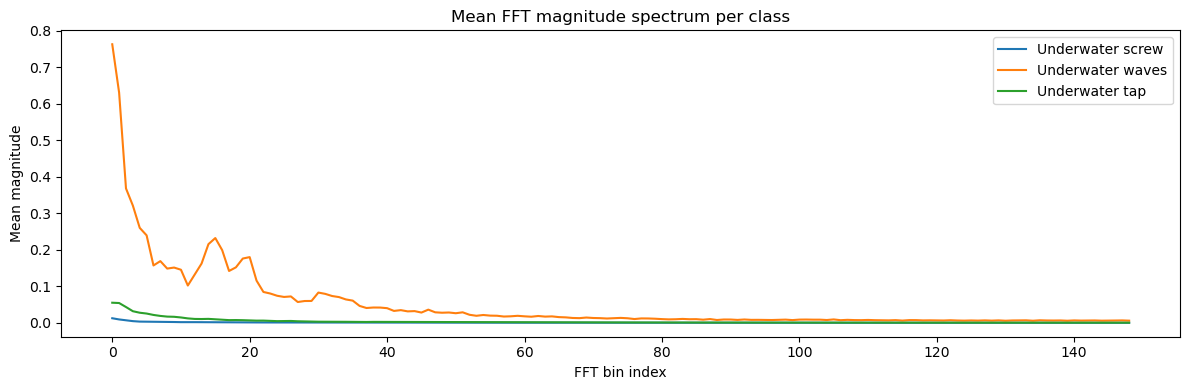

In [6]:
import matplotlib.pyplot as plt

freqs = np.fft.rfftfreq(150, d=np.mean([np.mean(np.diff(t)) for t in []]))  # approximate

plt.figure(figsize=(12, 4))
plt.plot(np.log1p(X_UWscrew.mean(axis=0)), label="Underwater screw")
plt.plot(np.log1p(X_UWwaves.mean(axis=0)), label="Underwater waves")
plt.plot(np.log1p(X_UWtap.mean(axis=0)), label="Underwater tap")
plt.xlabel("FFT bin index")
plt.ylabel("Mean magnitude")
plt.title("Mean FFT magnitude spectrum per class")
plt.legend()
plt.tight_layout()
plt.show()

### Spectrograms for disturbance types

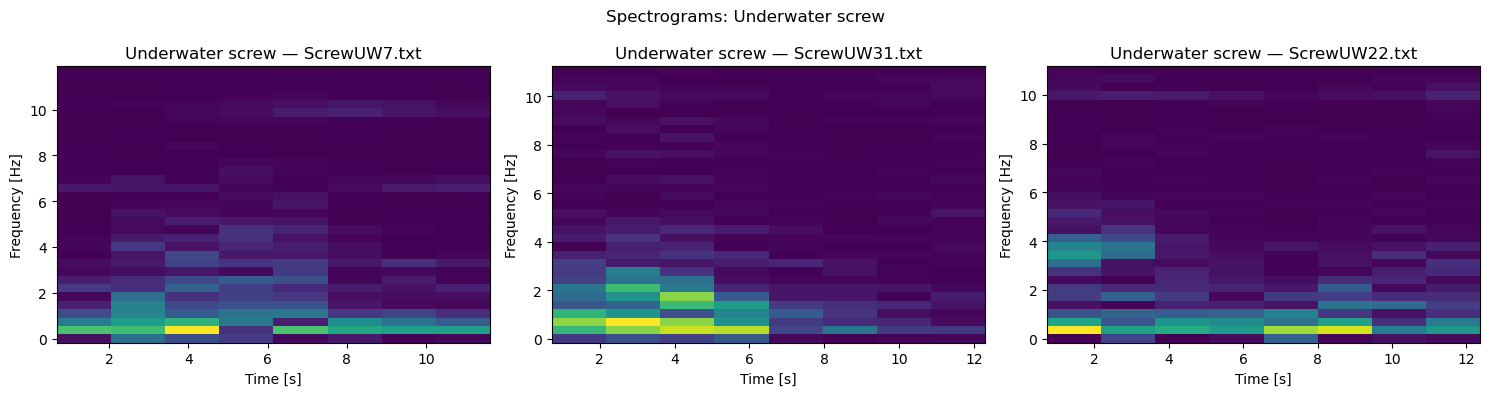

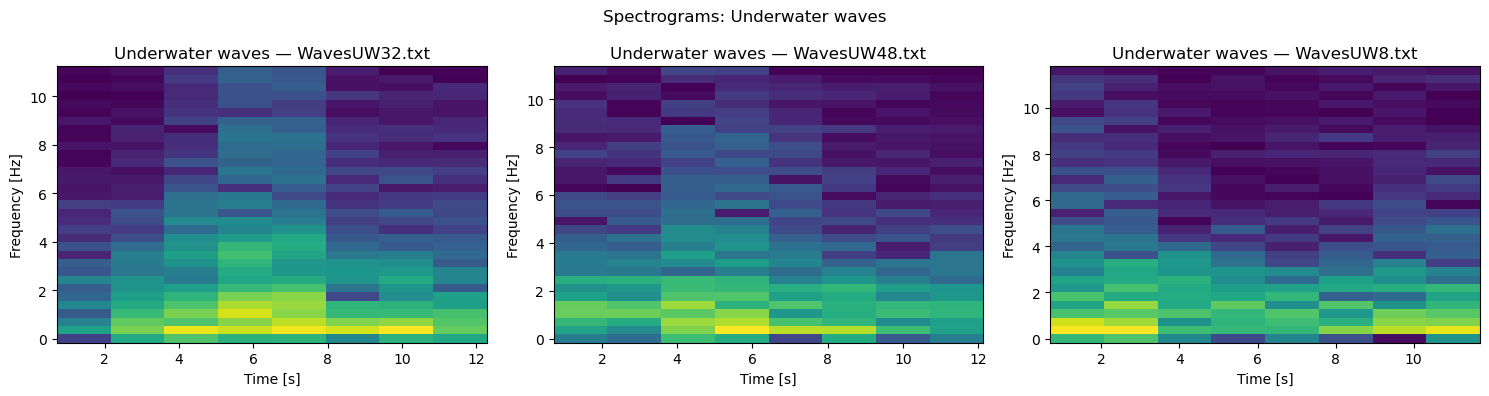

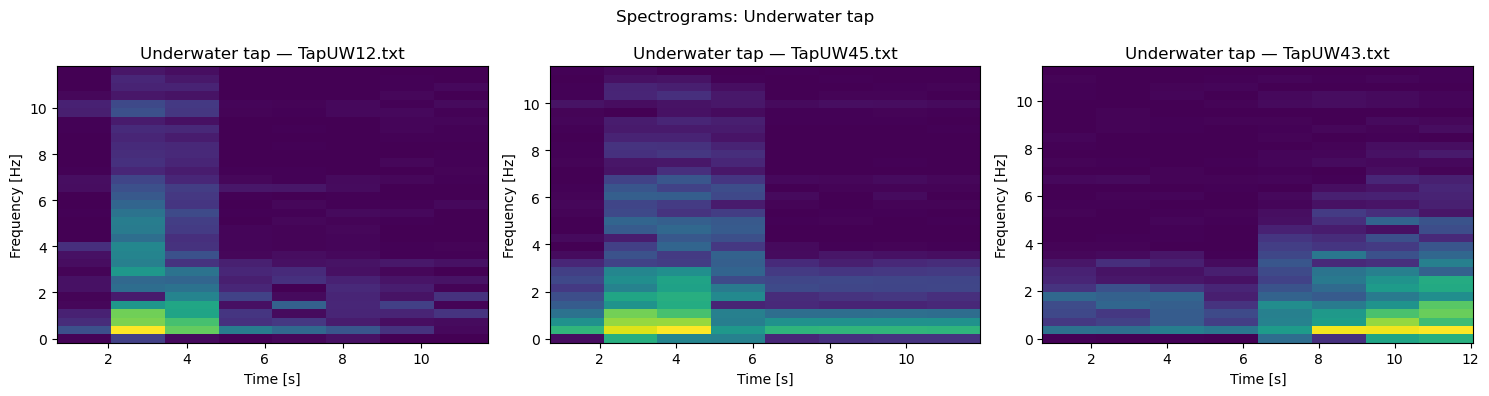

In [7]:
def plot_spectrograms(folder, label, n=3):
    all_files = list(Path(folder).glob("*.txt"))
    files = random.sample(all_files, min(n, len(all_files)))
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    
    for ax, file in zip(axes, files):
        t, signal = load_and_interpolate(file)
        dt = np.mean(np.diff(t))
        fs = 1 / dt
        
        f, tt, Sxx = spectrogram(signal, fs=fs, nperseg=64, noverlap=32)
        ax.pcolormesh(tt, f, 10*np.log10(Sxx + 1e-10), cmap="viridis")
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Frequency [Hz]")
        ax.set_title(f"{label} — {file.name}")
    
    plt.suptitle(f"Spectrograms: {label}")
    plt.tight_layout()
    plt.show()

plot_spectrograms("Saved data/UW_screw", "Underwater screw")
plot_spectrograms("Saved data/UW_waves", "Underwater waves")
plot_spectrograms("Saved data/UW_tap", "Underwater tap")

## Random Forest ML classification

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [9]:
# x and y for classification using random forest

X_UW = np.vstack([X_UWscrew, X_UWwaves, X_UWtap])

y_UW = np.concatenate([
    np.zeros(len(X_UWscrew)),
    np.ones(len(X_UWwaves)),
    np.full(len(X_UWtap), 2)
])

                  precision    recall  f1-score   support

Underwater screw       0.70      0.70      0.70        10
Underwater waves       0.91      1.00      0.95        10
  Underwater tap       0.67      0.60      0.63        10

        accuracy                           0.77        30
       macro avg       0.76      0.77      0.76        30
    weighted avg       0.76      0.77      0.76        30



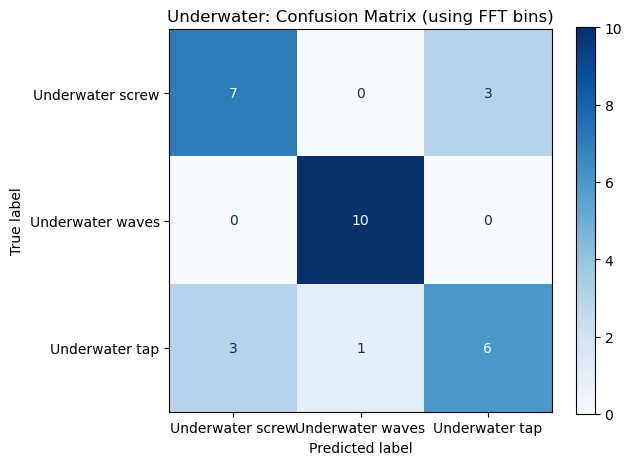

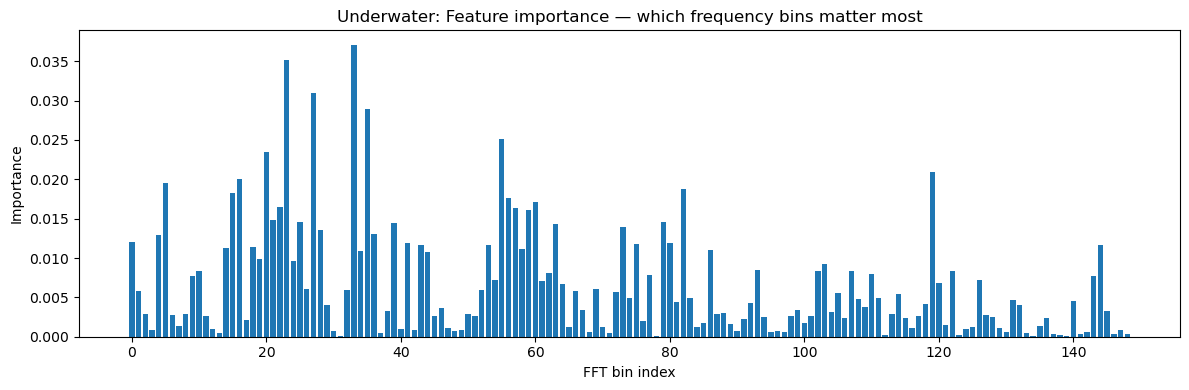

In [10]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_UW, y_UW, test_size=0.2, stratify=y_UW
)

# Train
clf = RandomForestClassifier(n_estimators=200)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Underwater screw", "Underwater waves", "Underwater tap"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Underwater screw", "Underwater waves", "Underwater tap"])
disp.plot(cmap="Blues")
plt.title("Underwater: Confusion Matrix (using FFT bins)")
plt.tight_layout()
plt.savefig("confusion_matrix_UW5.png", dpi=150)
plt.show()

# Feature importance
importances = clf.feature_importances_
plt.figure(figsize=(12, 4))
plt.bar(range(len(importances)), importances)
plt.xlabel("FFT bin index")
plt.ylabel("Importance")
plt.title("Underwater: Feature importance — which frequency bins matter most")
plt.tight_layout()
plt.savefig("feature_importance_UW5.png", dpi=150)
plt.show()

##### Cross-validation

In [12]:
cv_scores = cross_val_score(clf, X_UW, y_UW, cv=5, scoring="accuracy")
print(f"Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Individual folds: {cv_scores}")

Cross-validation accuracy: 0.860 ± 0.093
Individual folds: [0.96666667 0.73333333 0.76666667 0.9        0.93333333]


## Analysis of underground measurements

In [13]:
X_UG_step = process_folder("Saved data/UG_step")
X_UG_dig = process_folder("Saved data/UG_dig")
X_UG_drill = process_folder("Saved data/UG_drill")

c:\Users\leach\miniforge3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\leach\miniforge3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


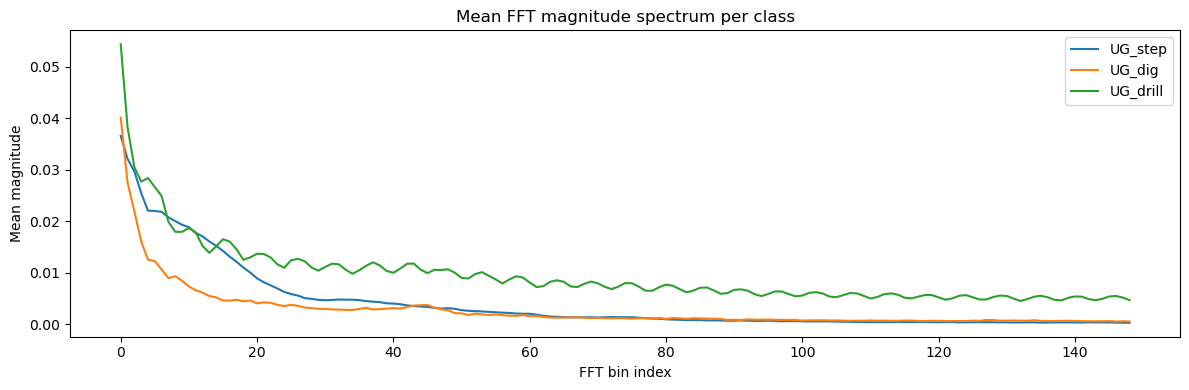

In [14]:
import matplotlib.pyplot as plt

freqs = np.fft.rfftfreq(150, d=np.mean([np.mean(np.diff(t)) for t in []]))  # approximate

plt.figure(figsize=(12, 4))
plt.plot(np.log1p(X_UG_step.mean(axis=0)), label="UG_step")
plt.plot(np.log1p(X_UG_dig.mean(axis=0)), label="UG_dig")
plt.plot(np.log1p(X_UG_drill.mean(axis=0)), label="UG_drill")
plt.xlabel("FFT bin index")
plt.ylabel("Mean magnitude")
plt.title("Mean FFT magnitude spectrum per class")
plt.legend()
plt.tight_layout()
plt.show()

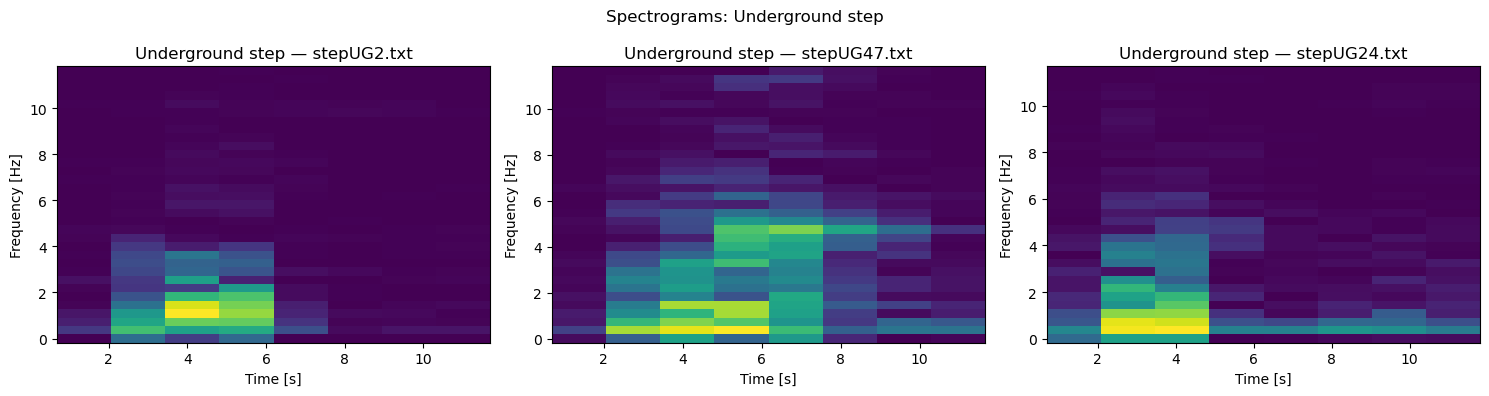

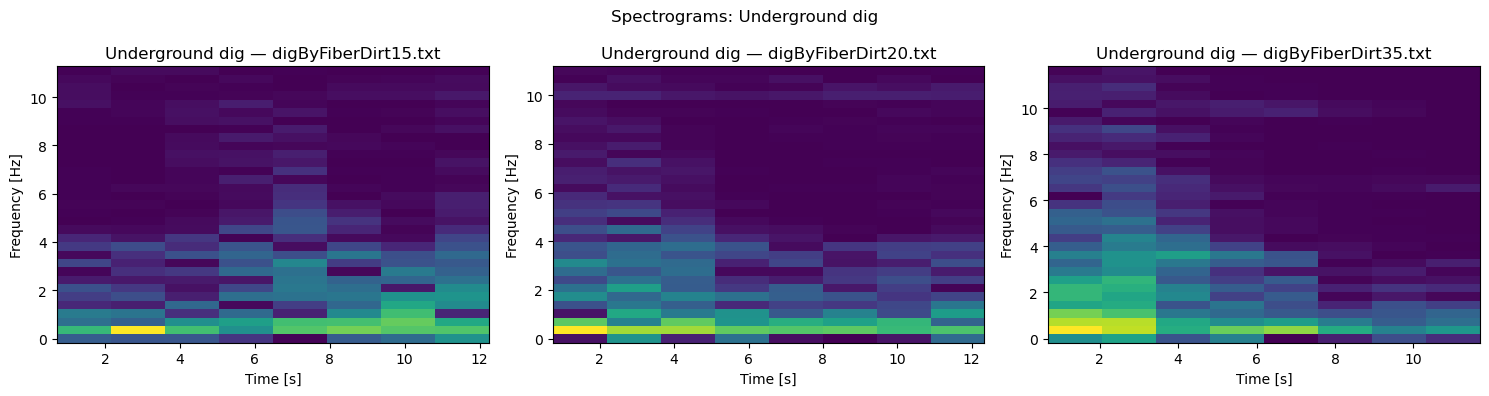

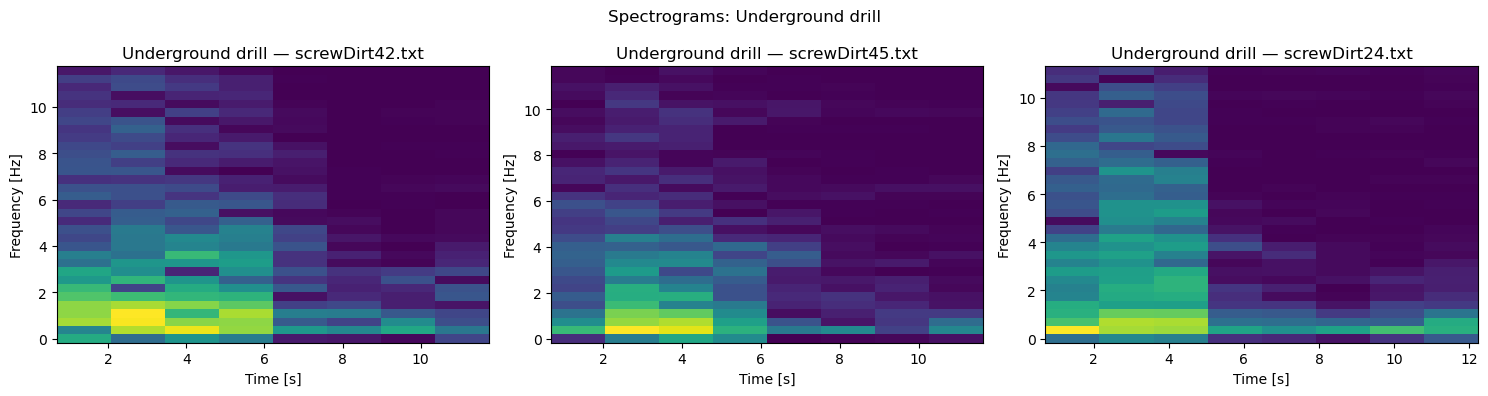

In [24]:
def plot_spectrograms(folder, label, n=3):
    all_files = list(Path(folder).glob("*.txt"))
    files = random.sample(all_files, min(n, len(all_files)))
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    
    for ax, file in zip(axes, files):
        t, signal = load_and_interpolate(file)
        dt = np.mean(np.diff(t))
        fs = 1 / dt
        
        f, tt, Sxx = spectrogram(signal, fs=fs, nperseg=64, noverlap=32)
        ax.pcolormesh(tt, f, 10*np.log10(Sxx + 1e-10), cmap="viridis")
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Frequency [Hz]")
        ax.set_title(f"{label} — {file.name}")
    
    plt.suptitle(f"Spectrograms: {label}")
    plt.tight_layout()
    plt.show()

plot_spectrograms("Saved data/UG_step", "Underground step")
plot_spectrograms("Saved data/UG_dig", "Underground dig")
plot_spectrograms("Saved data/UG_drill", "Underground drill")

In [16]:
# x and y for classification using random forest

X_UG = np.vstack([X_UG_step, X_UG_dig, X_UG_drill])

y_UG = np.concatenate([
    np.zeros(len(X_UG_step)),
    np.ones(len(X_UG_dig)),
    np.full(len(X_UG_drill), 2)
])

              precision    recall  f1-score   support

     UG step       1.00      0.70      0.82        10
      UG dig       0.47      0.70      0.56        10
    UG drill       0.62      0.50      0.56        10

    accuracy                           0.63        30
   macro avg       0.70      0.63      0.65        30
weighted avg       0.70      0.63      0.65        30



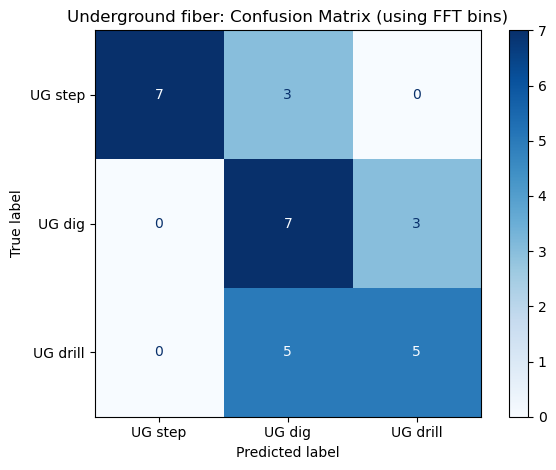

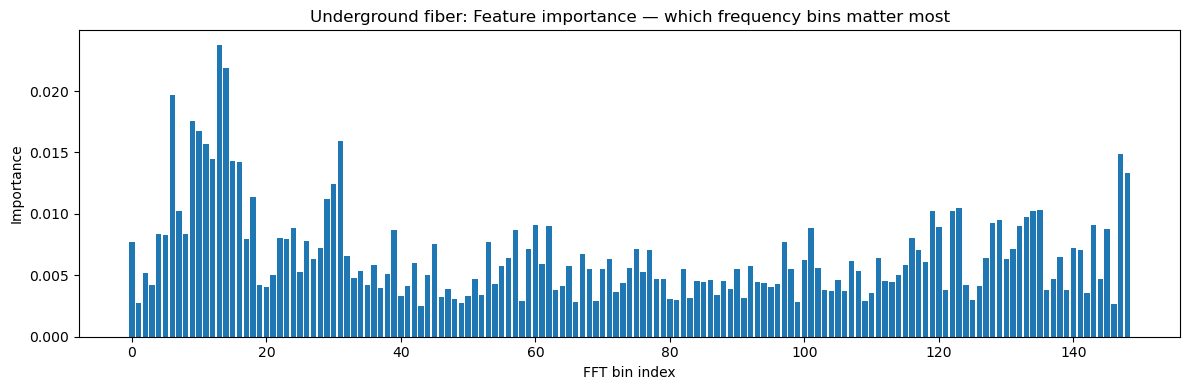

In [17]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_UG, y_UG, test_size=0.2, stratify=y_UG
)

# Train
clf = RandomForestClassifier(n_estimators=200)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["UG step", "UG dig", "UG drill"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["UG step", "UG dig", "UG drill"])
disp.plot(cmap="Blues")
plt.title("Underground fiber: Confusion Matrix (using FFT bins)")
plt.tight_layout()
#plt.savefig("confusion_matrix_UG5.png", dpi=150)
plt.show()

# Feature importance
importances = clf.feature_importances_
plt.figure(figsize=(12, 4))
plt.bar(range(len(importances)), importances)
plt.xlabel("FFT bin index")
plt.ylabel("Importance")
plt.title("Underground fiber: Feature importance — which frequency bins matter most")
plt.tight_layout()
#plt.savefig("feature_importance_UG5.png", dpi=150)
plt.show()

In [18]:
cv_scores = cross_val_score(clf, X_UG, y_UG, cv=5, scoring="accuracy")
print(f"Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Individual folds: {cv_scores}")

Cross-validation accuracy: 0.660 ± 0.074
Individual folds: [0.73333333 0.73333333 0.53333333 0.66666667 0.63333333]
